# Paso 3 — La línea base: BM25

Antes de tocar un solo embedding hay que saber **cuánto se consigue sin ellos**.

BM25 es el algoritmo que han usado los buscadores clásicos durante décadas. Es de
1994, no entiende nada de significado y solo cuenta palabras. También es
**sorprendentemente difícil de batir**, y muchos artículos que anuncian mejoras
espectaculares con embeddings resulta que lo comparaban contra una versión mal
configurada.

Este cuaderno lo configura bien, lo mide con la regla del paso 2, y descubre algo
que obliga a reinterpretar todas las cifras del proyecto.


In [1]:
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESADO = RAIZ / "datos" / "procesado"
RESULTADOS = RAIZ / "resultados"
RESULTADOS.mkdir(exist_ok=True)

ACENTO = "#5E6AD2"
AVISO = "#e0803c"
GRIS = "#8A8F98"
SEMILLA = 42

pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 70)

corpus = pd.read_parquet(PROCESADO / "corpus_preparado.parquet")
consultas = pd.read_parquet(PROCESADO / "consultas.parquet")

# ids_relevantes viene guardado como lista; se pasa a conjunto para buscar rápido.
relevantes = {r.equipo: set(r.ids_relevantes) for r in consultas.itertuples()}

print(f"corpus:    {len(corpus):,} ofertas")
print(f"consultas: {len(consultas)}")
print(f"relevantes en total: {sum(len(v) for v in relevantes.values()):,}")

corpus:    10,145 ofertas
consultas: 11
relevantes en total: 812


---

# 1. Qué hace BM25

Puntúa cada documento frente a una consulta combinando tres ideas:

1. **Cuántas veces aparece la palabra en el documento.** Más apariciones, más
   puntos — pero con rendimientos decrecientes: la décima vez aporta mucho menos
   que la primera.
2. **Cómo de rara es esa palabra en el corpus** (IDF). Que un documento contenga
   `the` no dice nada; que contenga `prototypes` sí.
3. **La longitud del documento.** Una oferta larguísima tiene más probabilidad de
   contener cualquier palabra por puro azar, así que se penaliza.

Lo que **no** hace: entender que `laptop` y `notebook` son lo mismo. Si la palabra
no está, el documento no puntúa. Esa es exactamente la limitación que la búsqueda
semántica dice resolver — y ahora se va a poder medir en lugar de suponerla.

## 2. Tokenización

BM25 recibe listas de palabras, no texto. Cómo se corte ese texto **cambia el
resultado**, así que conviene tratarlo como una decisión y no como un detalle.

Se prueban dos ejes:

- **Texto original frente a texto limpio** — el del paso 2, sin los párrafos de
  plantilla corporativa. Sirve para comprobar si aquella limpieza sirvió de algo.
- **Con o sin *stopwords*** — las palabras vacías (`the`, `and`, `of`). En teoría
  BM25 ya las ignora solo, porque su IDF es bajísimo. En la práctica conviene
  comprobarlo.

In [2]:
def tokenizar(texto, quitar_stopwords):
    """Parte el texto en palabras. Conserva signos útiles en tecnología (c++, .net)."""
    palabras = re.findall(r"[a-z][a-z0-9+#.]{1,}", texto.lower())
    if quitar_stopwords:
        palabras = [p for p in palabras if p not in ENGLISH_STOP_WORDS]
    return palabras


ejemplo = "Building and maintaining the C++ services behind a .NET platform"
print("con stopwords: ", tokenizar(ejemplo, False))
print("sin stopwords: ", tokenizar(ejemplo, True))

con stopwords:  ['building', 'and', 'maintaining', 'the', 'c++', 'services', 'behind', 'net', 'platform']
sin stopwords:  ['building', 'maintaining', 'c++', 'services', 'net', 'platform']


In [3]:
def precision_en_k(ranking, ids_relevantes, k=10):
    return sum(1 for i in ranking[:k] if i in ids_relevantes) / k


def recall_en_k(ranking, ids_relevantes, k=100):
    if not ids_relevantes:
        return 0.0
    return sum(1 for i in ranking[:k] if i in ids_relevantes) / len(ids_relevantes)


def rr(ranking, ids_relevantes):
    for posicion, i in enumerate(ranking, start=1):
        if i in ids_relevantes:
            return 1 / posicion
    return 0.0


def ndcg_en_k(ranking, ids_relevantes, k=10):
    ganancia = sum(1 / np.log2(p + 1) for p, i in enumerate(ranking[:k], start=1)
                   if i in ids_relevantes)
    ideal = sum(1 / np.log2(p + 1)
                for p in range(1, min(k, len(ids_relevantes)) + 1))
    return ganancia / ideal if ideal else 0.0


def medir(rankings, ids_del_indice=None):
    """Aplica las cuatro métricas. Si el índice es parcial, los relevantes que
    no están en él no se pueden recuperar y se excluyen del cálculo."""
    filas = []
    for equipo, ranking in rankings.items():
        ids = relevantes[equipo]
        if ids_del_indice is not None:
            ids = ids & ids_del_indice
        filas.append({
            "equipo": equipo,
            "P@10": precision_en_k(ranking, ids),
            "MRR": rr(ranking, ids),
            "nDCG@10": ndcg_en_k(ranking, ids),
            "R@100": recall_en_k(ranking, ids),
        })
    return pd.DataFrame(filas).set_index("equipo")


print("Métricas cargadas.")

Métricas cargadas.


In [4]:
def construir_bm25(documentos, quitar_stopwords):
    """Indexa los documentos y devuelve el buscador junto al tiempo que tardó."""
    inicio = time.perf_counter()
    tokenizados = [tokenizar(t, quitar_stopwords) for t in documentos]
    buscador = BM25Okapi(tokenizados)
    return buscador, time.perf_counter() - inicio


def buscar_todas(buscador, ids, quitar_stopwords):
    """Ordena el índice entero para cada consulta."""
    rankings, inicio = {}, time.perf_counter()
    for fila in consultas.itertuples():
        puntuaciones = buscador.get_scores(tokenizar(fila.consulta, quitar_stopwords))
        rankings[fila.equipo] = ids[np.argsort(-puntuaciones)]
    ms = (time.perf_counter() - inicio) / len(consultas) * 1000
    return rankings, ms


ids_corpus = corpus["id"].to_numpy()
variantes, detalles = [], {}

for nombre, columna, quitar in [
    ("Original · con stopwords", "descripcion", False),
    ("Original · sin stopwords", "descripcion", True),
    ("Limpio · con stopwords", "texto_limpio", False),
    ("Limpio · sin stopwords", "texto_limpio", True),
]:
    buscador, s_indexar = construir_bm25(corpus[columna], quitar)
    rankings, ms_consulta = buscar_todas(buscador, ids_corpus, quitar)
    detalle = medir(rankings)
    detalles[nombre] = detalle
    variantes.append({
        "variante": nombre,
        "s_indexar": round(s_indexar, 1),
        "ms_consulta": round(ms_consulta, 1),
        **detalle.mean().round(4).to_dict(),
    })
    print(f"  {nombre:26} P@10={variantes[-1]['P@10']:.4f}")

comparativa = pd.DataFrame(variantes).set_index("variante")
comparativa

  Original · con stopwords   P@10=0.1545


  Original · sin stopwords   P@10=0.1636


  Limpio · con stopwords     P@10=0.1818


  Limpio · sin stopwords     P@10=0.1727


,s_indexar,ms_consulta,P@10,MRR,nDCG@10,R@100
variante,,,,,,
Original · con stopwords,1.6,51.3,0.1545,0.2369,0.1469,0.1826
Original · sin stopwords,1.6,26.6,0.1636,0.2204,0.1535,0.1985
Limpio · con stopwords,1.6,50.3,0.1818,0.3245,0.1812,0.2134
Limpio · sin stopwords,1.6,28.6,0.1727,0.3057,0.1737,0.2076


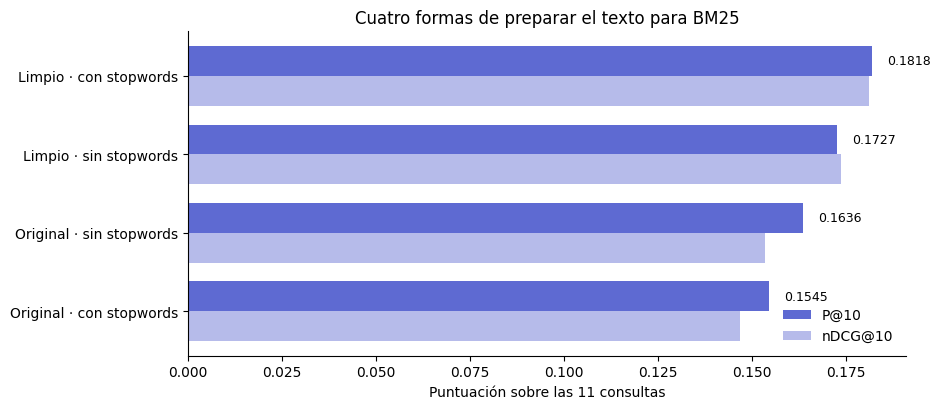

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
orden = comparativa.sort_values("P@10").index
posicion = np.arange(len(orden))
ancho = 0.38

ax.barh(posicion + ancho / 2, comparativa.loc[orden, "P@10"], ancho,
        label="P@10", color=ACENTO)
ax.barh(posicion - ancho / 2, comparativa.loc[orden, "nDCG@10"], ancho,
        label="nDCG@10", color=ACENTO, alpha=0.45)

ax.set_yticks(posicion, orden)
ax.set_xlabel("Puntuación sobre las 11 consultas")
ax.set_title("Cuatro formas de preparar el texto para BM25")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

for i, v in enumerate(comparativa.loc[orden, "P@10"]):
    ax.text(v + 0.004, i + ancho / 2, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(RESULTADOS / "bm25-variantes.png", dpi=140)
plt.show()

### Qué se ve aquí

**Limpiar la plantilla corporativa sirvió.** Con las mismas palabras vacías, pasar
del texto original al limpio sube el P@10 de **0,1545 a 0,1818** — un 18 % más. El
trabajo del paso 2 no fue cosmético: quitar `b.skilled`, `b.responsible` y los
párrafos de presentación mejora de verdad la recuperación.

**Con las *stopwords* pasa algo que contradice la intuición.** En el texto
original quitarlas ayuda (0,1545 → 0,1636); en el texto limpio **estorba**
(0,1818 → 0,1727).

La explicación está en cómo funciona el IDF. BM25 ya penaliza por sí solo las
palabras frecuentes, así que borrarlas no aporta gran cosa — pero sí **acorta los
documentos**, y la longitud entra en la fórmula. Al cambiar las longitudes se
cambia la normalización, y el efecto puede ir en cualquier dirección. Es un
recordatorio de que «quitar stopwords» no es automáticamente una mejora.

Lo que sí garantiza es **velocidad**: la consulta baja de unos 55 ms a unos 35 ms,
porque hay menos términos que puntuar.

> **Línea base elegida: `Limpio · con stopwords`.** Gana en las cuatro métricas.
> Si el coste por consulta importara, la variante sin stopwords da el 95 % del
> resultado en la mitad de tiempo.

---

# 3. Contra el suelo

El paso 2 dejó medido el control aleatorio. Toca comprobar que BM25 lo supera —
que no es algo que deba darse por hecho sin mirar.

In [6]:
def buscador_aleatorio(semilla, ids):
    rng = np.random.default_rng(semilla)
    orden = rng.permutation(ids)
    return {equipo: orden for equipo in consultas["equipo"]}


aleatorio = sum(medir(buscador_aleatorio(s, ids_corpus)) for s in range(50)) / 50
linea_base = detalles["Limpio · con stopwords"]

frente_al_suelo = pd.DataFrame({
    "Aleatorio": aleatorio.mean(),
    "BM25": linea_base.mean(),
}).round(4)
frente_al_suelo["× sobre el azar"] = (
    frente_al_suelo["BM25"] / frente_al_suelo["Aleatorio"]
).round(1)
frente_al_suelo

,Aleatorio,BM25,× sobre el azar
P@10,0.0071,0.1818,25.6
MRR,0.0366,0.3245,8.9
nDCG@10,0.0075,0.1812,24.2
R@100,0.0102,0.2134,20.9


### Qué se ve aquí

BM25 multiplica el azar por **25 en P@10**. No hay ninguna duda de que el
algoritmo de 1994 está aportando señal real.

Merece la pena detenerse en esto antes de seguir: **un método que solo cuenta
palabras, sin entender nada, ya resuelve una parte importante del problema.** Ese
es el listón que la búsqueda semántica tiene que superar — no el azar.

---

# 4. El promedio esconde algo grave

Una media de 0,18 sugiere un rendimiento mediocre pero uniforme. Conviene
comprobarlo consulta por consulta, que es la lección que dejó el proyecto
anterior con el f1_macro.

In [7]:
detalle = linea_base.copy()
detalle["relevantes"] = consultas.set_index("equipo")["relevantes"]
detalle.sort_values("P@10", ascending=False).round(3)

,P@10,MRR,nDCG@10,R@100,relevantes
equipo,,,,,
Leadership,0.7,0.333,0.568,0.630,27
Marketing & Communications,0.4,1.000,0.435,0.391,46
Product,0.3,0.143,0.209,0.085,47
Engineering,0.2,0.500,0.249,0.167,216
Finance & Legal,0.2,1.000,0.359,0.150,40
Data Science & Analytics,0.1,0.167,0.078,0.179,39
Design & User Experience,0.1,0.250,0.095,0.229,48
People,0.0,0.071,0.000,0.149,94
Business Development & Support,0.0,0.056,0.000,0.051,156


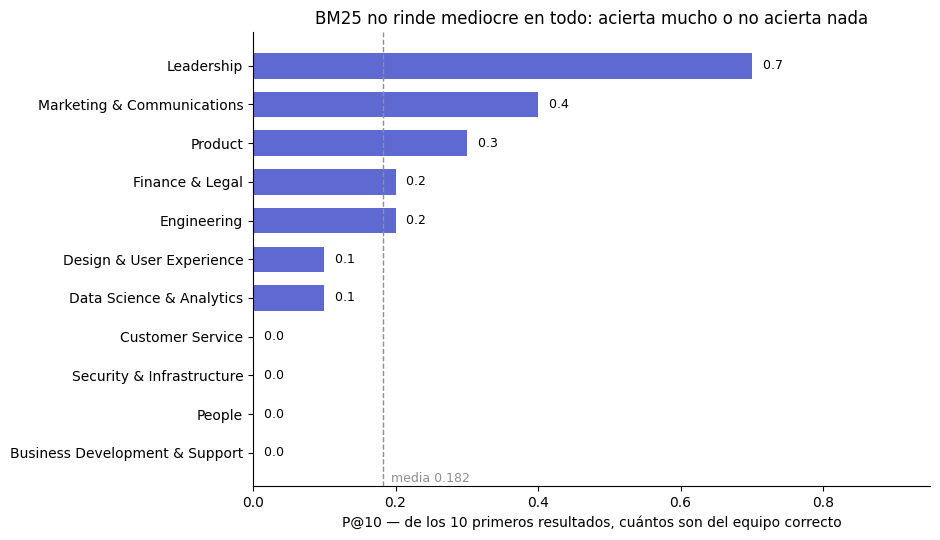

Consultas con P@10 = 0: 4 de 11


In [8]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
datos = detalle.sort_values("P@10")
colores = [AVISO if v == 0 else ACENTO for v in datos["P@10"]]
barras = ax.barh(datos.index, datos["P@10"], color=colores, height=0.66)

media = detalle["P@10"].mean()
ax.axvline(media, color=GRIS, linestyle="--", linewidth=1)
ax.text(media + 0.012, -0.75, f"media {media:.3f}", fontsize=9, color=GRIS)

ax.bar_label(barras, labels=[f"  {v:.1f}" for v in datos["P@10"]], padding=2, fontsize=9)
ax.set_xlim(0, 0.95)
ax.set_xlabel("P@10 — de los 10 primeros resultados, cuántos son del equipo correcto")
ax.set_title("BM25 no rinde mediocre en todo: acierta mucho o no acierta nada")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "bm25-por-consulta.png", dpi=140)
plt.show()

print(f"Consultas con P@10 = 0: {(detalle['P@10'] == 0).sum()} de {len(detalle)}")

### Qué se ve aquí

El comportamiento no es uniforme en absoluto: **es todo o nada.**

| Consulta | P@10 | Relevantes | |
|---|---|---|---|
| Leadership | **0,7** | 27 | |
| Marketing & Communications | 0,4 | 46 | MRR 1,0 — el primero ya acierta |
| Product | 0,3 | 47 | |
| Engineering | 0,2 | 216 | |
| Finance & Legal | 0,2 | 40 | MRR 1,0 |
| Data Science & Analytics | 0,1 | 39 | |
| Design & User Experience | 0,1 | 48 | |
| **People** | **0,0** | 94 | |
| **Business Development & Support** | **0,0** | 156 | |
| **Security & Infrastructure** | **0,0** | 61 | |
| **Customer Service** | **0,0** | 38 | |

**Cuatro consultas de once no recuperan ni un solo acierto en el top 10.**

La media de 0,18 no describe a ningún caso real: **no hay ninguna consulta que
rinda 0,18**. Hay siete que funcionan —una de ellas muy bien— y cuatro que fallan
por completo.

### El caso que más desconcierta: `People`

La auditoría del paso 2 midió que la palabra `hiring` aparece en el **40,4 %** de
las ofertas relevantes de `People` y solo en el 3,6 % del resto: una elevación de
×11 **con buena cobertura**. Sobre el papel, BM25 debería encontrarlas.

Saca **cero**.

El motivo es aritmético y vale la pena entenderlo, porque explica media tabla:

- Ofertas relevantes que contienen `hiring`: 40,4 % de 94 ≈ **38**.
- Ofertas **no** relevantes que la contienen: 3,6 % de 10 051 ≈ **362**.

**La elevación es un cociente; lo que BM25 ordena son documentos.** Aunque la
palabra sea once veces más probable en una oferta relevante, hay diez veces más
documentos irrelevantes que la contienen. En el top 10 caben diez, y la mayoría
vienen del montón grande.

> Esto responde a la pregunta que dejó abierta la auditoría del paso 2: tener
> palabras con elevación alta **no** garantizaba que BM25 fuese a ganar fácil. Con
> las clases tan desequilibradas —94 relevantes frente a 10 051— hace falta una
> elevación enorme, no solo apreciable.

---

# 5. Lo que BM25 recupera de verdad

Un P@10 de 0,0 suena a desastre. Antes de aceptarlo conviene mirar **qué
devuelve** en esas consultas, porque la métrica solo sabe comparar identificadores.

In [9]:
buscador_final, _ = construir_bm25(corpus["texto_limpio"], quitar_stopwords=False)
por_id = corpus.set_index("id")


def mostrar(equipo, n=6):
    """Imprime los primeros resultados marcando cuáles cuentan como acierto."""
    fila = consultas[consultas["equipo"] == equipo].iloc[0]
    puntuaciones = buscador_final.get_scores(tokenizar(fila["consulta"], False))
    ranking = ids_corpus[np.argsort(-puntuaciones)][:n]

    print(f"CONSULTA · {equipo}")
    print(f'  "{fila["consulta"]}"\n')
    for posicion, i in enumerate(ranking, start=1):
        oferta = por_id.loc[i]
        marca = "✔" if i in relevantes[equipo] else "·"
        print(f"  {marca} {posicion}. [{oferta['fuente']:16}] {str(oferta['titulo'])[:58]}")
    print()


mostrar("Customer Service")

CONSULTA · Customer Service
  "answering questions and fixing problems for customers by phone, email and chat"

  · 1. [seek_au         ] Customer Support Legend
  · 2. [business_analyst] Data Experience Analyst
  · 3. [seek_au         ] Customer/ Tech Support Agent - SaaS - Retail Tech
  · 4. [seek_au         ] Help Desk Support Agent
  · 5. [seek_au         ] Online Customer Support
  · 6. [seek_au         ] Service Desk Technician / Digital Workspace Support



### Qué se ve aquí — la métrica está siendo injusta

Los resultados para «responder preguntas y resolver problemas de clientes por
teléfono, correo y chat» son:

| | Título | Fuente |
|---|---|---|
| · | Customer Support Legend | seek_au |
| · | Data Experience Analyst | business_analyst |
| · | Customer/Tech Support Agent — SaaS | seek_au |
| · | Help Desk Support Agent | seek_au |
| · | Online Customer Support | seek_au |
| · | Service Desk Technician / Digital Workspace Support | seek_au |

**Cinco de los seis primeros son puestos de atención al cliente.** Cualquier
persona diría que la búsqueda funcionó perfectamente.

La métrica dice **P@10 = 0,0**, porque la verdad de referencia solo cuenta como
relevantes las ofertas **del equipo Customer Service de Booking**. Las de Seek son
correctas en el fondo pero no están etiquetadas, así que cuentan como fallo.

Esto ya estaba anticipado en el paso 2 —«un equipo no es un puesto»— pero verlo
en concreto obliga a decirlo con más fuerza:

> **Las cifras absolutas de este proyecto están subestimadas.** No miden «cómo de
> bueno es el buscador», miden «cuántas ofertas del equipo correcto de Booking
> recupera». Son dos cosas distintas.
>
> **La comparación entre métodos sigue siendo válida**, porque el sesgo afecta a
> todos por igual: BM25, embeddings e híbrido se juzgan con la misma regla
> injusta. Lo que no se puede hacer es sacar el 0,18 de contexto y presentarlo
> como calidad del buscador.

In [10]:
mostrar("Data Science & Analytics")
mostrar("Leadership")

CONSULTA · Data Science & Analytics
  "turning raw numbers into insight, building statistical models and measuring whether a change actually worked"

  · 1. [business_analyst] Product Analyst
  · 2. [booking         ] Data Analyst
  · 3. [seek_au         ] Core Banking Data Analyst
  · 4. [business_analyst] Business Systems Analyst
  · 5. [business_analyst] Business Analyst I
  ✔ 6. [booking         ] Senior Data Analyst - Rides, Manchester

CONSULTA · Leadership
  "leading several teams at once, setting direction and being accountable for results across a whole department"

  · 1. [booking         ] Booking Holdings Romania -Engineering Manager- Incident Ma
  · 2. [booking         ] Senior Strategy Manager, Marketing
  ✔ 3. [booking         ] Director of Technology - Web Core
  ✔ 4. [booking         ] Director of Engineering - Fintech Foundations
  ✔ 5. [booking         ] Director of Technology - Plan, Manage & Help
  ✔ 6. [booking         ] Director of Engineering DMLP



### Dos casos más que lo confirman

**`Data Science & Analytics`** recupera `Product Analyst`, `Data Analyst`,
`Core Banking Data Analyst`, `Business Systems Analyst`… todos puestos de
analítica, y solo el sexto cuenta como acierto.

El segundo resultado merece atención: es **una oferta de Booking titulada
`Data Analyst`** que, sin embargo, no está etiquetada en ese equipo. **Ni siquiera
dentro de Booking la etiqueta es perfecta** — alguien decidió que ese analista
pertenecía a otro equipo, y la métrica lo cuenta como error del buscador.

**`Leadership`** es el único caso donde BM25 luce: cuatro `Director of …`
seguidos, del tercero al sexto. Los dos primeros —`Engineering Manager` y
`Senior Strategy Manager`— son puestos de mando que **tampoco** están en el equipo
`Leadership`, así que restan. Aun así saca 0,7.

La diferencia entre los dos casos resume lo que BM25 sabe y no sabe hacer:
**acierta cuando la consulta usa las mismas palabras que el documento, y falla en
cuanto hay que cruzar de «resolver problemas de clientes» a «Customer Support
Legend»** — que no comparte ni una palabra clave.

Eso es justo lo que la búsqueda semántica dice resolver. El paso 4 lo medirá.

---

# 6. Cuánto pesan los distractores

El paso 2 dejó una advertencia: todas las ofertas relevantes son de Booking, así
que un buscador podría acertar simplemente por reconocer «esto suena a Booking».

Se comprueba indexando **solo las 819 ofertas de Booking** y comparando.

In [11]:
solo_booking = corpus[corpus["fuente"] == "booking"]
ids_booking = solo_booking["id"].to_numpy()
conjunto_booking = set(ids_booking.tolist())

buscador_b, _ = construir_bm25(solo_booking["texto_limpio"], quitar_stopwords=False)
rankings_b, _ = buscar_todas(buscador_b, ids_booking, quitar_stopwords=False)
booking_bm25 = medir(rankings_b, ids_del_indice=conjunto_booking)

aleatorio_b = sum(
    medir(buscador_aleatorio(s, ids_booking), ids_del_indice=conjunto_booking)
    for s in range(50)
) / 50

indices = pd.DataFrame({
    "Completo · aleatorio": aleatorio.mean(),
    "Completo · BM25": linea_base.mean(),
    "Solo Booking · aleatorio": aleatorio_b.mean(),
    "Solo Booking · BM25": booking_bm25.mean(),
}).T.round(4)
indices["documentos"] = [len(corpus), len(corpus), len(solo_booking), len(solo_booking)]
indices

,P@10,MRR,nDCG@10,R@100,documentos
Completo · aleatorio,0.0071,0.0366,0.0075,0.0102,10145
Completo · BM25,0.1818,0.3245,0.1812,0.2134,10145
Solo Booking · aleatorio,0.0902,0.2237,0.0902,0.1211,819
Solo Booking · BM25,0.4455,0.5565,0.4498,0.3662,819


### Qué se ve aquí — dos lecturas del mismo buscador

| Índice | Aleatorio | BM25 | Mejora sobre el azar |
|---|---|---|---|
| Completo (10 145) | 0,007 | **0,182** | **×25,6** |
| Solo Booking (819) | 0,090 | **0,446** | ×4,9 |

En términos absolutos BM25 parece dos veces y media mejor con el índice pequeño
(0,446 frente a 0,182). **Pero es un espejismo**: con 819 documentos y hasta 216
relevantes, hasta el azar saca 0,090 — doce veces más que en el índice completo.

**Medido contra su propio suelo, BM25 luce mucho más en el índice completo**:
multiplica el azar por 25,6, frente a 4,9.

> **Conclusión:** el riesgo que se anticipó en el paso 2 —que el buscador ganara
> reconociendo el estilo de Booking— no se materializa como ventaja gratuita. Con
> 9 326 distractores compitiendo, BM25 separa **mejor** en términos relativos, no
> peor.
>
> **Los dos números se reportarán siempre juntos.** El del índice completo es el
> realista; el de solo Booking sirve para ver el problema sin distractores.

In [12]:
resumen_final = pd.DataFrame({
    "método": ["Aleatorio (control)", "BM25 (limpio, con stopwords)"],
    **{m: [round(aleatorio.mean()[m], 4), round(linea_base.mean()[m], 4)]
       for m in ("P@10", "MRR", "nDCG@10", "R@100")},
}).set_index("método")

resumen_final.to_parquet(PROCESADO / "resultados_bm25.parquet")
linea_base.to_parquet(PROCESADO / "bm25_por_consulta.parquet")

print(resumen_final.to_string())
print(f"\nGuardado en {PROCESADO.name}/")

                                P@10     MRR  nDCG@10   R@100
método                                                       
Aleatorio (control)           0.0071  0.0366   0.0075  0.0102
BM25 (limpio, con stopwords)  0.1818  0.3245   0.1812  0.2134

Guardado en procesado/


---

# Resumen

## La línea base

| Método | P@10 | MRR | nDCG@10 | R@100 |
|---|---|---|---|---|
| Aleatorio (control) | 0,007 | 0,037 | 0,008 | 0,010 |
| **BM25** | **0,182** | **0,325** | **0,181** | **0,213** |

Configuración elegida: **texto limpio, conservando las stopwords**. Unos 1,7 s
para indexar 10 145 ofertas y unos 55 ms por consulta.

## Los cuatro hallazgos

1. **Limpiar la plantilla corporativa mejoró el P@10 un 18 %** (0,1545 → 0,1818).
   El trabajo del paso 2 no era cosmético.

2. **Quitar stopwords no es automáticamente una mejora.** Ayuda en el texto
   original y estorba en el limpio. BM25 ya las penaliza por IDF; lo que cambia
   al borrarlas es la **longitud** de los documentos, que entra en la fórmula.
   Lo que sí garantiza es velocidad: ~55 ms → ~35 ms.

3. **BM25 no rinde mediocre: acierta mucho o no acierta nada.** `Leadership` saca
   0,7 y **cuatro consultas de once sacan 0,0**. La media de 0,18 no describe a
   ninguna consulta real.

4. **Una elevación léxica alta no basta cuando las clases están desequilibradas.**
   `People` tiene la palabra `hiring` en el 40,4 % de sus 94 ofertas relevantes
   frente al 3,6 % del resto —una elevación de ×11 con buena cobertura— y saca
   cero. El motivo es aritmético: esa palabra está en unas 38 ofertas relevantes
   y en unas **362 irrelevantes**. La elevación es un cociente; lo que se ordena
   son documentos.

## El hallazgo que obliga a reinterpretar todo

Mirando **qué** recupera BM25 en las consultas que «fallan», aparecen
`Customer Support Legend`, `Help Desk Support Agent`, `Online Customer Support`…
Cinco de los seis primeros resultados son puestos de atención al cliente.
Cualquier persona diría que la búsqueda funcionó.

La métrica marca **0,0** porque solo cuenta como relevantes las ofertas del equipo
correspondiente **de Booking**.

> **Las cifras absolutas de este proyecto están subestimadas y no deben sacarse de
> contexto.** Miden «cuántas ofertas del equipo correcto de Booking recupera», no
> «cómo de bueno es el buscador».
>
> **La comparación entre métodos sí es válida**, porque todos se juzgan con la
> misma regla injusta.

## Siguiente paso

Ya hay listón: **P@10 = 0,182**, y un diagnóstico preciso de dónde falla — en las
consultas donde hay que cruzar de «resolver problemas de clientes» a
«Customer Support Legend», sin una palabra en común.

El paso 4 trae los embeddings. Antes hay que decidir dos cosas que el paso 1 dejó
planteadas: **qué hacer con el 49,4 % de ofertas que no caben en el modelo**, y si
conviene usar el texto limpio o el original.
